<a href="https://colab.research.google.com/github/GiorgiKarazanashvili/cs666student/blob/main/CS666_Assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# loads numpy and matplotlib
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [ ]:
import torch # WE WILL BE USING PYTORCH THIS TIME,
             # IT IS MORE ADVANCED THAN KERAS BUT EXTREMELY POPULAR!
             # MOST OF THE CODE HERE IS READY TO GO JUST TRY TO UNDERSTAND IT!

In [ ]:
#
# CHECK IF THE GPU IS AVAILABLE ON CHIMERA21
#
if torch.cuda.is_available():
    device = 'cuda'
    print(torch.cuda.get_device_name(0))
else:
    device = 'cpu'
    print('GPU not available, using CPU!')

NVIDIA H200 MIG 1g.35gb


## 1. Data Processing. (10 points)

In [ ]:
### DOWNLOAD THE DATA
!wget https://cs666.org/data/mito.npz

--2026-04-24 17:29:30--  https://cs666.org/data/mito.npz
Resolving cs666.org (cs666.org)... 185.199.109.153, 185.199.110.153, 185.199.111.153, ...
Connecting to cs666.org (cs666.org)|185.199.109.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 37610178 (36M) [application/octet-stream]
Saving to: ‘mito.npz’

mito.npz            100%[===================>]  35.87M  87.8MB/s    in 0.4s    

2026-04-24 17:29:31 (87.8 MB/s) - ‘mito.npz’ saved [37610178/37610178]



In [ ]:
# The data includes images and manually segmented masks.
loaded = np.load('mito.npz')
images = loaded['arr_0'][0]
masks = loaded['arr_0'][1]

In [ ]:
# PROCESS THE IMAGES
images = (images - images.min()) / (images.max() - images.min())
masks = masks.astype(bool).astype(float)

In [ ]:
# TODO: What does the above code do?
# TODO:
# images normalizes the images to make the pixel values fall between 0 and 1
# masks converts the masks to boolean and back to float so the intermediate values are either 1 or 0

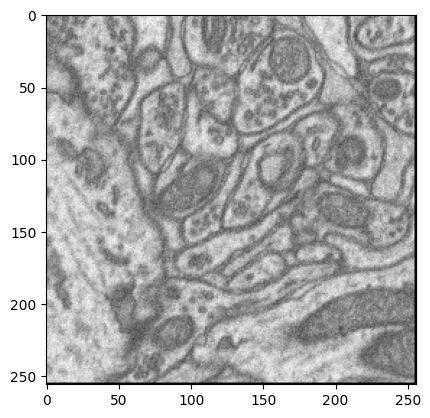

In [ ]:
imshow(images[0], cmap='gray')

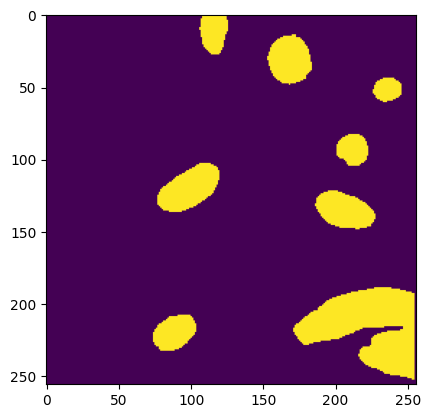

In [ ]:
imshow(masks[0])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    images, masks, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [ ]:
# TODO: What does the above code do?
# TODO:
# First dataset is split into 70% train set 30% test&validation set
# Second splits the remainding 30% subset in half to get 15% test set and 15%validation set

## 2. Make the Data Pytorch-ready! (10 points)

In [ ]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [ ]:
import albumentations as A

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
])

val_transform = A.Compose([])

In [ ]:
# TODO: What does the above code do?
# TODO: We are applying augmentations randomly: horizontal flip, vertical flip, and 90 degree rotation
# each applied randomply at 50% probabilty. We do this to increase variability in the dataset.

In [ ]:
class MitoDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        mask = self.masks[idx]

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        # add channel dimension: (H, W) -> (1, H, W)
        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        return image, mask

In [ ]:
train_dataset = MitoDataset(X_train, y_train, transform=train_transform)
val_dataset = MitoDataset(X_val, y_val, transform=val_transform)
test_dataset = MitoDataset(X_test, y_test, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

In [ ]:
# TODO: What does the above code do?
# TODO: MitoDataset wraps the numpy arrays into a PyTorch Dataset so PyTorch can read the data.
# It applies transforms, adds a channel, and converts to tensor
# DataLoader handles batching, 16 at a time, shuffling being active only during training,
# and have 2 workers for parallel loading

## 3. Configure the Classifier! (30 points)

In [ ]:
#
# SETUP U-NET
#
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights=None,
    in_channels=1,
    classes=1
).to(device)

In [ ]:
# DICE LOSS FUNCTION
dice_loss = smp.losses.DiceLoss(mode="binary")
bce_loss = nn.BCEWithLogitsLoss()

def loss_fn(pred, target):
    return 0.5 * bce_loss(pred, target) + 0.5 * dice_loss(pred, target)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
# DICE METRIC
def dice_score(pred, target, threshold=0.5, eps=1e-7):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    intersection = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))

    dice = (2.0 * intersection + eps) / (union + eps)
    return dice.mean().item()

In [ ]:
# SINGLE EPOCH, PYTORCH IS A BIT MORE COMPLEX HERE..
def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    total_dice = 0.0

    for images_batch, masks_batch in loader:
        images_batch = images_batch.to(device)
        masks_batch = masks_batch.to(device)

        with torch.set_grad_enabled(training):
            preds = model(images_batch)
            loss = loss_fn(preds, masks_batch)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item()
        total_dice += dice_score(preds, masks_batch)

    avg_loss = total_loss / len(loader)
    avg_dice = total_dice / len(loader)
    return avg_loss, avg_dice

## 4. Train the U-Net! (20 points)

In [ ]:
#
# TRAINING LOOP
#
num_epochs = 10

train_losses, val_losses = [], []
train_dices, val_dices = [], []

best_val_dice = 0.0

for epoch in range(num_epochs):
    train_loss, train_dice = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_dice = run_epoch(model, val_loader, optimizer=None)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_dices.append(train_dice)
    val_dices.append(val_dice)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "best_mito_model.pth")

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss={train_loss:.4f}, train_dice={train_dice:.4f} | "
        f"val_loss={val_loss:.4f}, val_dice={val_dice:.4f}"
    )

print("Best val dice:", best_val_dice)

Epoch 1/10 | train_loss=0.6428, train_dice=0.5003 | val_loss=0.5685, val_dice=0.0000
Epoch 2/10 | train_loss=0.3583, train_dice=0.8179 | val_loss=0.3149, val_dice=0.7468
Epoch 3/10 | train_loss=0.1934, train_dice=0.8663 | val_loss=0.4155, val_dice=0.5454
Epoch 4/10 | train_loss=0.1234, train_dice=0.8772 | val_loss=0.1387, val_dice=0.8583
Epoch 5/10 | train_loss=0.0860, train_dice=0.9053 | val_loss=0.1192, val_dice=0.8411
Epoch 6/10 | train_loss=0.0710, train_dice=0.9163 | val_loss=0.0814, val_dice=0.8991
Epoch 7/10 | train_loss=0.0665, train_dice=0.9178 | val_loss=0.0787, val_dice=0.8961
Epoch 8/10 | train_loss=0.0596, train_dice=0.9242 | val_loss=0.0702, val_dice=0.9041
Epoch 9/10 | train_loss=0.0506, train_dice=0.9352 | val_loss=0.0605, val_dice=0.9150
Epoch 10/10 | train_loss=0.0500, train_dice=0.9350 | val_loss=0.0961, val_dice=0.8577
Best val dice: 0.9150002939360482


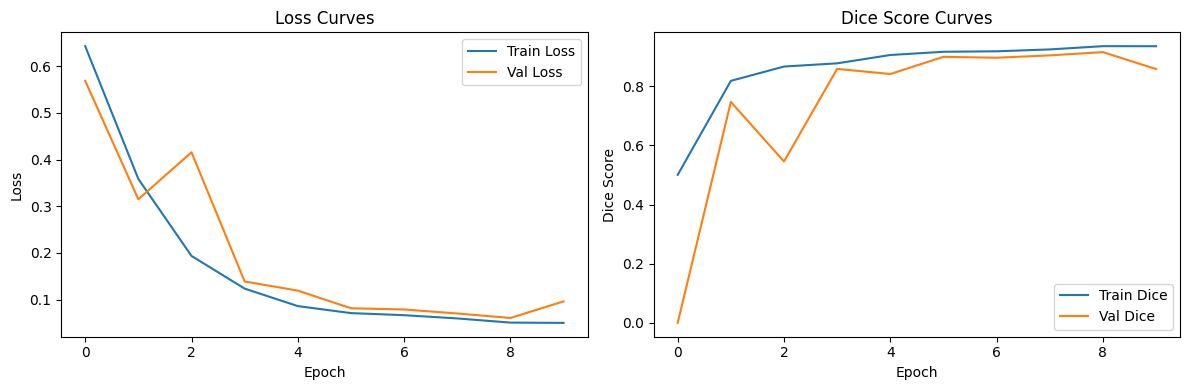

In [ ]:
# TODO: Plot the loss and dice curves!
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_title('Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(train_dices, label='Train Dice')
axes[1].plot(val_dices, label='Val Dice')
axes[1].set_title('Dice Score Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice Score')
axes[1].legend()

plt.tight_layout()

In [ ]:
# TODO: Do these plots look good?
# TODO: The curves are trending into the right direction, loss goes down and dice goes up.
# The Validation curves are jumpy in early epochs, which is more promenets in val dice. This likely
# happens due to validation set being small, causing singular bad batches to skew the numbers.
#However afer 4 epochs, the curves smoothen out and converge well.

## 5. Testing the U-Net. (20 points)

In [ ]:
# EVALUATE THE MODEL ON THE TEST DATA
model.load_state_dict(torch.load("best_mito_model.pth", map_location=device))
test_loss, test_dice = run_epoch(model, test_loader, optimizer=None)

print("Test loss:", round(test_loss, 4))
print("Test dice:", round(test_dice, 4))

Test loss: 0.0646
Test dice: 0.9145


In [ ]:
# Scores are good but let's do some Detective Work to see if
# the classifier actually works well!

# RUN PREDICTIONS
model.eval()

images_batch, masks_batch = next(iter(test_loader))
images_batch = images_batch.to(device)

with torch.no_grad():
    preds = model(images_batch)
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

images_batch = images_batch.cpu().numpy()
masks_batch = masks_batch.numpy()
preds = preds.cpu().numpy()

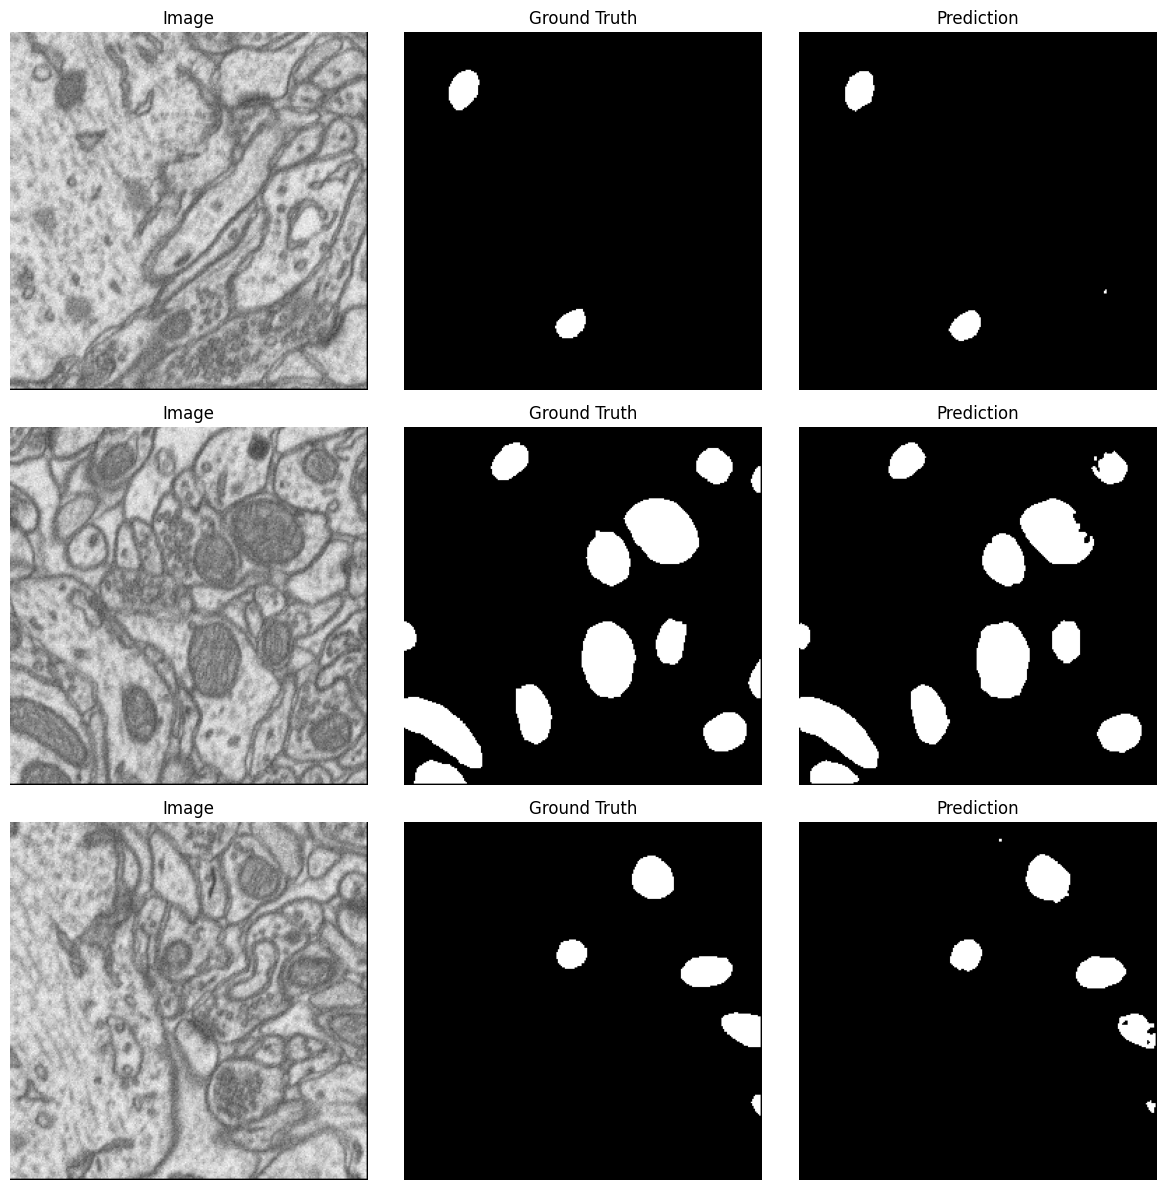

In [ ]:
# SHOW EXAMPLE PREDICTIONS OF THE TEST SET
n = 3

plt.figure(figsize=(12, 4 * n))

for i in range(n):
    plt.subplot(n, 3, 3*i + 1)
    plt.imshow(images_batch[i, 0], cmap="gray")
    plt.title("Image")
    plt.axis("off")

    plt.subplot(n, 3, 3*i + 2)
    plt.imshow(masks_batch[i, 0], cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(n, 3, 3*i + 3)
    plt.imshow(preds[i, 0], cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 6. Interpretation. (10 points)

In [ ]:
# TODO: Do you think the classifier works well?
# TODO: The classifier works well. The predicted masks closely match the ground truth: correct location
# and shape. However there are some holes, highly irregular shapes get cut-off (2nd example middle cell
# with a small peak), and there are couple false positives (white speks) and some false negatives (2nd
# example right edge 2 partial cells not detected)
# Overall a dice score of 0.915 seems to be correctly represented

## Bonus: Improve the results. (33 points)

In [ ]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ElasticTransform(p=0.3), #more transformations
    A.RandomBrightnessContrast(p=0.3), #more transformations
])

val_transform = A.Compose([])


In [ ]:
# Try to get better performance and show an improved Dice score on the test set!
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",        # bigger encoder than resnet18
    encoder_weights="imagenet",     # pretrained weights
    in_channels=1,
    classes=1
).to(device)

dice_loss = smp.losses.DiceLoss(mode="binary")
bce_loss = nn.BCEWithLogitsLoss()

def loss_fn(pred, target):
    return 0.5 * bce_loss(pred, target) + 0.5 * dice_loss(pred, target)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# setup scheduler because around epoch 9 val loss starts picking back up, showing that learning rate
# might be too high
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

In [ ]:
num_epochs = 20 #more epochs to let scheduler work (we have it set to work after 3 epochs, the
# val loss starter going up around epoch 9, not enough room)

train_losses, val_losses = [], []
train_dices, val_dices = [], []
best_val_dice = 0.0

for epoch in range(num_epochs):
    train_loss, train_dice = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_dice = run_epoch(model, val_loader, optimizer=None)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_dices.append(train_dice)
    val_dices.append(val_dice)

    scheduler.step(val_loss) #added scheduler to the architecture

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "best_mito_model_improved.pth")

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss={train_loss:.4f}, train_dice={train_dice:.4f} | "
        f"val_loss={val_loss:.4f}, val_dice={val_dice:.4f}"
    )

print("Best val dice:", best_val_dice)

Epoch 1/20 | train_loss=0.4592, train_dice=0.6821 | val_loss=0.3532, val_dice=0.7138
Epoch 2/20 | train_loss=0.1898, train_dice=0.8820 | val_loss=0.1383, val_dice=0.8981
Epoch 3/20 | train_loss=0.1013, train_dice=0.9093 | val_loss=0.0861, val_dice=0.9071
Epoch 4/20 | train_loss=0.0723, train_dice=0.9231 | val_loss=0.0604, val_dice=0.9359
Epoch 5/20 | train_loss=0.0583, train_dice=0.9354 | val_loss=0.0573, val_dice=0.9338
Epoch 6/20 | train_loss=0.0520, train_dice=0.9380 | val_loss=0.0536, val_dice=0.9350
Epoch 7/20 | train_loss=0.0514, train_dice=0.9361 | val_loss=0.0459, val_dice=0.9441
Epoch 8/20 | train_loss=0.0508, train_dice=0.9346 | val_loss=0.1397, val_dice=0.8192
Epoch 9/20 | train_loss=0.0541, train_dice=0.9311 | val_loss=0.0530, val_dice=0.9358
Epoch 10/20 | train_loss=0.0440, train_dice=0.9433 | val_loss=0.0424, val_dice=0.9457
Epoch 11/20 | train_loss=0.0386, train_dice=0.9498 | val_loss=0.0352, val_dice=0.9551
Epoch 12/20 | train_loss=0.0373, train_dice=0.9509 | val_loss=0

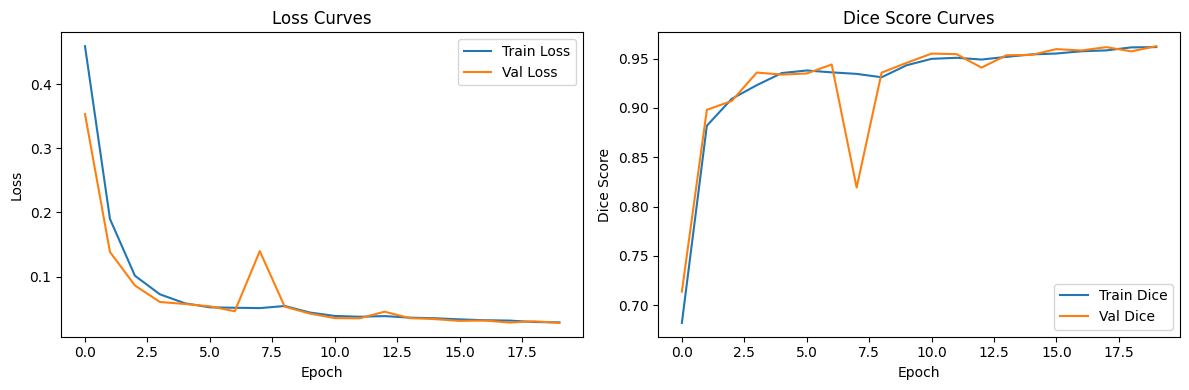

In [ ]:
# TODO: Plot the loss and dice curves!
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_title('Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(train_dices, label='Train Dice')
axes[1].plot(val_dices, label='Val Dice')
axes[1].set_title('Dice Score Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice Score')
axes[1].legend()

plt.tight_layout()

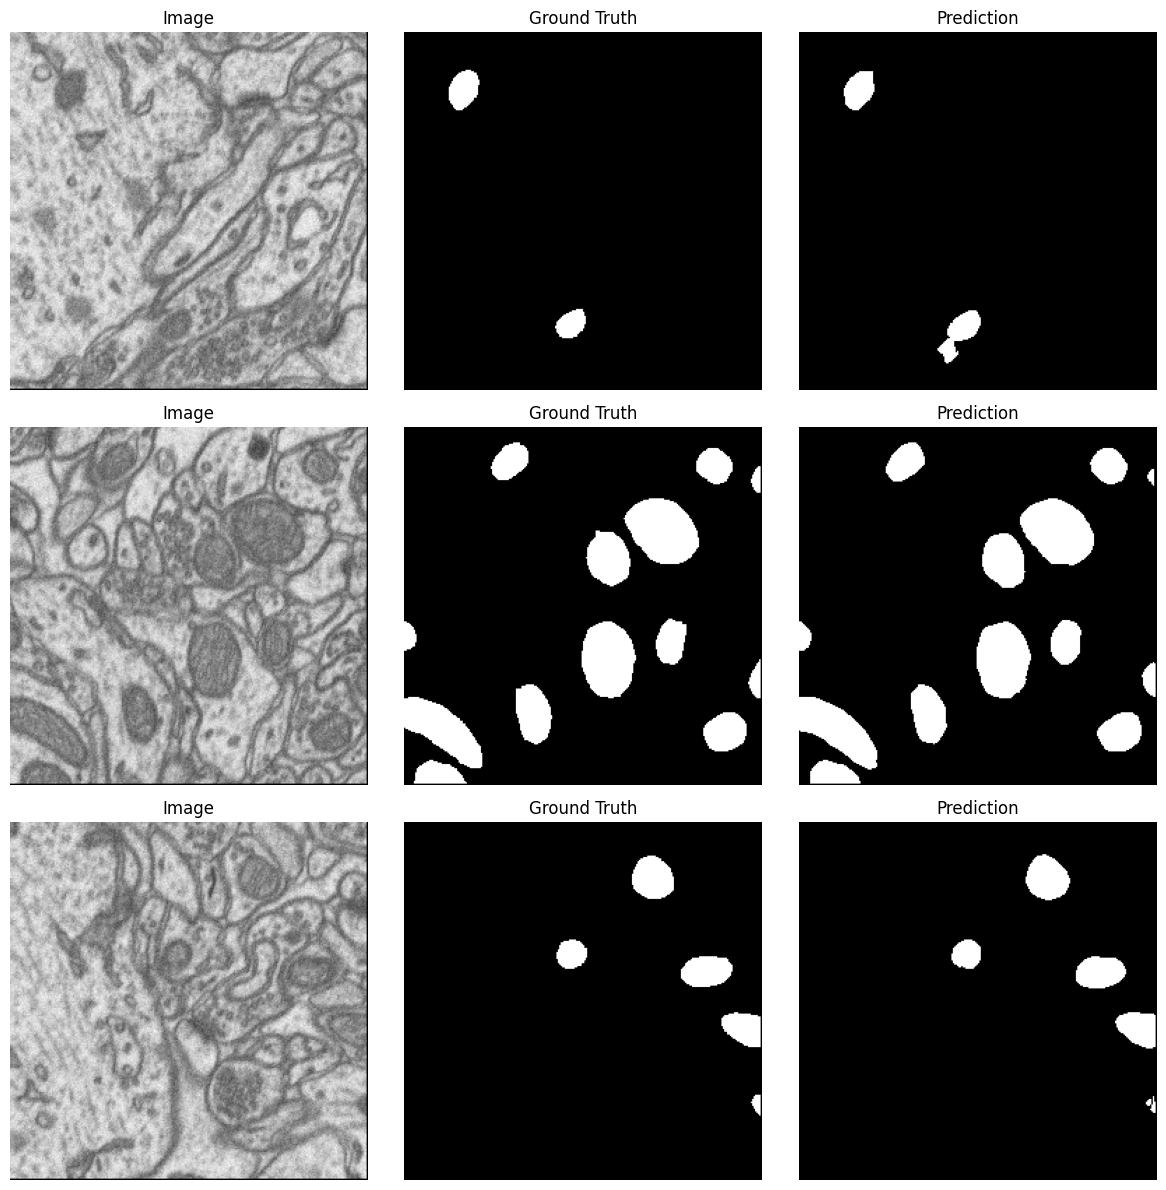

In [ ]:
model.load_state_dict(torch.load("best_mito_model_improved.pth", map_location=device))
model.eval()

images_batch, masks_batch = next(iter(test_loader))
images_batch = images_batch.to(device)

with torch.no_grad():
    preds = model(images_batch)
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

images_batch = images_batch.cpu().numpy()
masks_batch = masks_batch.numpy()
preds = preds.cpu().numpy()

n = 3

plt.figure(figsize=(12, 4 * n))

for i in range(n):
    plt.subplot(n, 3, 3*i + 1)
    plt.imshow(images_batch[i, 0], cmap="gray")
    plt.title("Image")
    plt.axis("off")

    plt.subplot(n, 3, 3*i + 2)
    plt.imshow(masks_batch[i, 0], cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(n, 3, 3*i + 3)
    plt.imshow(preds[i, 0], cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#
# You made it!!
#
#                 _ ___                /^^\ /^\  /^^\_
#     _          _@)@) \            ,,/ '` ~ `'~~ ', `\.
#   _/o\_ _ _ _/~`.`...'~\        ./~~..,'`','',.,' '  ~:
#  / `,'.~,~.~  .   , . , ~|,   ,/ .,' , ,. .. ,,.   `,  ~\_
# ( ' _' _ '_` _  '  .    , `\_/ .' ..' '  `  `   `..  `,   \_
#  ~V~ V~ V~ V~ ~\ `   ' .  '    , ' .,.,''`.,.''`.,.``. ',   \_
#   _/\ /\ /\ /\_/, . ' ,   `_/~\_ .' .,. ,, , _/~\_ `. `. '.,  \_
#  < ~ ~ '~`'~'`, .,  .   `_: ::: \_ '      `_/ ::: \_ `.,' . ',  \_
#   \ ' `_  '`_    _    ',/ _::_::_ \ _    _/ _::_::_ \   `.,'.,`., \-,-,-,_,_,
#    `'~~ `'~~ `'~~ `'~~  \(_)(_)(_)/  `~~' \(_)(_)(_)/ ~'`\_.._,._,'_;_;_;_;_;
#